In [ ]:
!pip install sentence-transformers torch torchvision torchaudio
!pip install torch-geometric torch-scatter torch-sparse torch-cluster torch-spline-conv -f https://data.pyg.org/whl/torch-2.2.0+cpu.html
!pip install networkx

Looking in links: https://data.pyg.org/whl/torch-2.2.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.5/511.5 kB 13.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 53.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 774.1/774.1 kB 55.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.4/215.4 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.6 MB/s eta 0:00:00


In [ ]:
import json
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, RobertaTokenizer, RobertaForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

In [ ]:
import os
import json
import numpy as np

# ---------------------------
# Config
# ---------------------------
DATA_FOLDER = "/content/preprocessed_sentences"   # folder where your doc JSONs are stored
OUTPUT_FOLDER = "argument_labels"                # folder to save labeled results
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# UPDATED: Added "Decision"
LABELS = ["Claim", "Evidence", "Rule", "Decision", "Background"]

In [ ]:
from transformers import pipeline

# Load zero-shot classifier
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


In [ ]:
import re

def refine_label(sentence: str, raw_label: str) -> str:
    s = sentence.lower()

    # Court heading / case metadata → Background
    if re.search(r"(district court|civil action no|case no|division|plaintiff|defendant)", s):
        return "Background"

    # Pure citations/statutes → Rule
    if re.search(r"\b\d+\s*usc|\b§|\btitle\s+\d+", s):
        return "Rule"

    # Jurisdiction & procedural boilerplate → Background
    if "jurisdiction" in s or "venue" in s or "consent decree" in s:
        return "Background"

    # Allegations/denials → Claim
    if re.search(r"(alleged|alleges|discriminated|violated|denies|wrongful|liable)", s):
        return "Claim"

    # Evidence signals
    if re.search(r"(exhibit|affidavit|report|testimony|document|investigation)", s):
        return "Evidence"

    # Default to model's output if no rule matches
    return raw_label

In [ ]:
import os
import json
from transformers import pipeline

# ----------------------
# Zero-shot classifier
# ----------------------
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# UPDATED: Candidate labels now include the new "Decision" type
LABELS = [
    "Claim",
    "Evidence",
    "Rule",
    "Decision",
    "Background"
]

# ----------------------
# Folder paths
# ----------------------
DATA_FOLDER = "preprocessed_sentences"
OUTPUT_FILE = "classified_sentences.json"

all_sentences = []

# Threshold for confident zero-shot prediction
CONF_THRESHOLD = 0.7

for filename in os.listdir(DATA_FOLDER):
    if filename.endswith(".json"):
        file_path = os.path.join(DATA_FOLDER, filename)
        with open(file_path, "r", encoding="utf-8") as f:
            case_data = json.load(f)

        for sent in case_data:
            text = sent["sentence"]

            # Zero-shot classification: multi-label
            result = classifier(text, LABELS, multi_label=True)
            labels_scores = list(zip(result["labels"], result["scores"]))

            # Pick highest scoring label
            top_label, top_score = labels_scores[0]

            # If top score is below threshold, assign Background
            if top_score < CONF_THRESHOLD:
                final_label = "Background"
            else:
                # UPDATED: Determine final label, checking for both "Background" and "Decision"
                if "Background" in top_label:
                    final_label = "Background"
                elif "Decision" in top_label:
                    final_label = "Decision"
                else:
                    final_label = top_label

            # Note: The refine_label function (Cell 5) is not used here in the final classification loop.
            # If you intended to use it, you would call: final_label = refine_label(text, final_label)

            # Save raw and final labels
            all_sentences.append({
                "sentence": text,
                "raw_label": top_label,
                "raw_score": top_score,
                "final_label": final_label
            })

# Save results
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_sentences, f, indent=2, ensure_ascii=False)

print(f"✅ Saved {len(all_sentences)} labeled sentences to {OUTPUT_FILE}")

# Preview
for item in all_sentences[:5]:
    print(f"Sentence: {item['sentence'][:80]}...")
    print(f" → Raw: {item['raw_label']} ({item['raw_score']:.2f}), Final: {item['final_label']}\n")

Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


✅ Saved 184 labeled sentences to classified_sentences.json
Sentence: i IN THE UNITED STATES DISTRICT COURT FOR THE SOUTHERN DISTRICT OF ALABAlVlA SOU...
 → Raw: Claim (0.87), Final: Claim

Sentence: ) CIVIL ACTION NO: 1:05-KO-M CONSENT DECREE The Equal Emplo)'lnent Opportunity C...
 → Raw: Decision (0.97), Final: Decision

Sentence: (Title and the Civil Rights Act of 42 U.S.C....
 → Raw: Claim (0.47), Final: Background

Sentence: In the Complaint, the Cornmission alleged that House of Philadelphia discriminat...
 → Raw: Decision (0.89), Final: Decision

Sentence: The Parties do not object to the jurisdiction of the Court over this action and ...
 → Raw: Decision (0.73), Final: Decision



In [ ]:
import json
from collections import defaultdict

# Load your classified file
with open("classified_sentences.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# Overall stats
total = len(data)
matches = sum(1 for item in data if item["raw_label"] == item["final_label"])
mismatches = total - matches

match_pct = (matches / total) * 100 if total > 0 else 0
mismatch_pct = 100 - match_pct

print("=== Overall Agreement ===")
print(f"Total sentences: {total}")
print(f"Matches: {matches} ({match_pct:.2f}%)")
print(f"Mismatches: {mismatches} ({mismatch_pct:.2f}%)\n")

# Per-final-label stats
label_stats = defaultdict(lambda: {"total": 0, "matches": 0})

for item in data:
    final = item["final_label"]
    label_stats[final]["total"] += 1
    if item["raw_label"] == final:
        label_stats[final]["matches"] += 1

print("=== Per-final-label Agreement ===")
for label, stats in label_stats.items():
    total_lbl = stats["total"]
    matches_lbl = stats["matches"]
    pct = (matches_lbl / total_lbl) * 100 if total_lbl > 0 else 0
    print(f"{label:12s} → {matches_lbl}/{total_lbl} match ({pct:.2f}%)")

=== Overall Agreement ===
Total sentences: 184
Matches: 148 (80.43%)
Mismatches: 36 (19.57%)

=== Per-final-label Agreement ===
Claim        → 46/46 match (100.00%)
Decision     → 32/32 match (100.00%)
Background   → 0/36 match (0.00%)
Rule         → 38/38 match (100.00%)
Evidence     → 32/32 match (100.00%)


In [ ]:
import numpy as np
import networkx as nx
from collections import Counter
from sentence_transformers import util, SentenceTransformer
import torch
import json
import os

# Define the boost factor for argumentative relations
ARGUMENT_BOOST = 1.3

# ---------------------------
# Load pre-classified sentences
# ---------------------------
DATA_FOLDER = "preprocessed_sentences"
CLASSIFIED_FILE = "classified_sentences.json"

with open(CLASSIFIED_FILE, "r", encoding="utf-8") as f:
    classified_data = json.load(f)

# Organize sentences per case (assuming case_id exists or by splitting files)
cases = [classified_data]

# ---------------------------
# Embedding model
# ---------------------------
embedder = SentenceTransformer("all-MiniLM-L6-v2")

# ---------------------------
# Build graphs
# ---------------------------
graphs = []

for case_idx, case in enumerate(cases, 1):
    G = nx.DiGraph()
    role_counter = Counter()

    # Step 1: Add nodes with final labels
    for idx, sent in enumerate(case):
        sent_text = sent["sentence"]
        label = sent["final_label"]
        role_counter[label] += 1
        G.add_node(idx, text=sent_text, role=label)

    print(f"Case {case_idx}: Roles - {dict(role_counter)}")

    # Step 2: Fallbacks for missing Claim / Evidence
    claims = [i for i in G.nodes if G.nodes[i]["role"] == "Claim"]
    supports = [i for i in G.nodes if G.nodes[i]["role"] in ["Evidence", "Rule", "Decision"]] # Only check for argument-supporting roles

    # Note: Fallback logic remains conservative, focusing on ensuring Claim/Evidence exist,
    # as promoting a generic sentence to "Decision" is often inaccurate.

    if not claims:  # promote first non-Background to Claim
        for i in G.nodes:
            if G.nodes[i]["role"] != "Background":
                G.nodes[i]["role"] = "Claim"
                claims.append(i)
                print(f"Case {case_idx}: No Claim found, promoted sentence {i} to Claim.")
                break

    if not supports:  # promote first non-Claim, non-Background to Evidence
        for i in G.nodes:
            if G.nodes[i]["role"] not in ["Claim", "Background"]:
                G.nodes[i]["role"] = "Evidence"
                supports.append(i)
                print(f"Case {case_idx}: No Evidence found, promoted sentence {i} to Evidence.")
                break

    if not claims or not supports:
        print(f"Case {case_idx} skipped (still missing Claim or Evidence after fallback).")
        continue

    # Step 3: Embed all sentences
    all_indices = list(G.nodes)
    all_texts = [G.nodes[i]["text"] for i in all_indices]
    embeddings = embedder.encode(all_texts, convert_to_tensor=True)

    # Step 4: Build edges - connect nodes if cosine similarity >= threshold

    threshold = 0.65
    cosine_scores = util.pytorch_cos_sim(embeddings, embeddings)

    for i, src_idx in enumerate(all_indices):
        scores = cosine_scores[i].cpu().numpy()
        connected = False

        for tgt_idx, score in enumerate(scores):
            if src_idx == tgt_idx:
                continue
            if score >= threshold:

                # --- UPDATED LOGIC: DETERMINE RELATION TYPE & APPLY BOOST ---
                src_role = G.nodes[src_idx]["role"]
                tgt_role = G.nodes[tgt_idx]["role"]

                relation = "related"
                boost = 1.0

                # Check for supports/justifies links to Claim OR Decision
                if src_role in ["Evidence", "Premise"] and tgt_role in ["Claim", "Decision"]:
                    relation = "supports"
                    boost = ARGUMENT_BOOST
                elif src_role == "Rule" and tgt_role in ["Claim", "Decision"]:
                    relation = "justifies"
                    boost = ARGUMENT_BOOST

                new_weight = float(score) * boost
                # --------------------------------------------------------

                G.add_edge(src_idx, tgt_idx, relation=relation, weight=new_weight)
                connected = True

        # Fallback: if no edges were added, connect to most similar neighbor
        if not connected:
            scores[src_idx] = -1
            tgt_idx = scores.argmax()
            score = scores[tgt_idx]

            # --- FALLBACK LOGIC: DETERMINE RELATION TYPE & APPLY BOOST ---
            src_role = G.nodes[src_idx]["role"]
            tgt_role = G.nodes[tgt_idx]["role"]

            relation = "related"
            boost = 1.0

            if src_role in ["Evidence", "Premise"] and tgt_role in ["Claim", "Decision"]:
                relation = "supports"
                boost = ARGUMENT_BOOST
            elif src_role == "Rule" and tgt_role in ["Claim", "Decision"]:
                relation = "justifies"
                boost = ARGUMENT_BOOST

            new_weight = float(score) * boost
            # --------------------------------------------------------

            G.add_edge(src_idx, tgt_idx, relation=relation, weight=new_weight)

    graphs.append(G)
    print(f"Case {case_idx}: Graph with {len(G.nodes)} nodes and {len(G.edges)} edges.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Case 1: Roles - {'Claim': 46, 'Decision': 32, 'Background': 36, 'Rule': 38, 'Evidence': 32}
Case 1: Graph with 184 nodes and 289 edges.


In [ ]:
import networkx as nx
import pickle
import os

os.makedirs("graphs", exist_ok=True)

# Saving graphs
for i, G in enumerate(graphs, 1):
    with open(f"graphs/case_{i}_graph.pkl", "wb") as f:
        pickle.dump(G, f)
    print(f"✅ Saved graph for Case {i}")

# Loading a graph
with open("graphs/case_1_graph.pkl", "rb") as f:
    G_loaded = pickle.load(f)

✅ Saved graph for Case 1


In [ ]:
import pickle
import networkx as nx
import matplotlib.pyplot as plt

# ------------------------------
# Visualization function updated for the new 'Decision' role color
# ------------------------------
def visualize_graph(G, title="Argument Graph"):
    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G, k=0.5, seed=42)

    # Role-based coloring (Updated to include Decision)
    role_colors = {
        "Claim": "lightgreen",
        "Evidence": "skyblue",
        "Rule": "orange",
        "Decision": "gold", # New color for Decision
        "Background": "lightgray"
    }
    node_colors = [role_colors.get(G.nodes[n]["role"], "lightgray") for n in G.nodes]

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2000, edgecolors="black")
    # Draw edges
    nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="->", width=1.5, edge_color="gray")
    # Labels
    node_labels = {n: f"{n}\n{G.nodes[n]['role']}" for n in G.nodes}
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=9)
    edge_labels = nx.get_edge_attributes(G, 'relation')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color="red", font_size=8)

    plt.title(title, fontsize=14)
    plt.axis("off")
    plt.show()

In [ ]:
import json
import networkx as nx
import torch
from sentence_transformers import SentenceTransformer, util

# Note: This metrics calculation relies on the structural connectivity determined by the initial threshold.
# If you want to use the *boosted* weights in a functional way (e.g., Weighted Degree Centrality),
# you would adjust the nx.degree_centrality call accordingly: nx.degree_centrality(G, weight='weight').

FILE_PATH = "classified_sentences.json"

with open(FILE_PATH, "r", encoding="utf-8") as f:
    sentences = json.load(f)

# Embedding model
embedder = SentenceTransformer("all-MiniLM-L6-v2")

# Thresholds and metrics
thresholds = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]
metrics_results = {}

all_texts = [sent["sentence"] for sent in sentences]
embeddings = embedder.encode(all_texts, convert_to_tensor=True)
all_indices = list(range(len(sentences)))

for threshold in thresholds:
    # Build the graph structure *only* based on the threshold (unweighted for standard metrics)
    G_metrics = nx.DiGraph()

    # Add nodes
    for idx, sent in enumerate(sentences):
        G_metrics.add_node(idx, text=sent["sentence"], role=sent["final_label"])

    # Build edges (using only the similarity score against the threshold)
    cosine_scores = util.pytorch_cos_sim(embeddings, embeddings)
    connected_list = [False] * len(all_indices)

    for i, src_idx in enumerate(all_indices):
        scores = cosine_scores[i].cpu().numpy()
        for tgt_idx, score in enumerate(scores):
            if src_idx == tgt_idx:
                continue
            if score >= threshold:
                # Add edge. Weight is set to 1.0 for unweighted metrics below.
                G_metrics.add_edge(src_idx, tgt_idx, weight=1.0)
                connected_list[src_idx] = True

        # Fallback: connect to most similar neighbor if isolated
        if not connected_list[src_idx]:
            scores[src_idx] = -1
            tgt_idx = scores.argmax()
            G_metrics.add_edge(src_idx, tgt_idx, weight=1.0)

    # Compute metrics (these are standard unweighted metrics)
    density = nx.density(G_metrics)
    degree_centrality = nx.degree_centrality(G_metrics)
    avg_centrality = sum(degree_centrality.values()) / len(G_metrics.nodes)
    clustering = nx.average_clustering(G_metrics.to_undirected())

    metrics_results[threshold] = {
        "density": density,
        "avg_centrality": avg_centrality,
        "clustering": clustering
    }

# Display results
print("Graph metrics for single case:\n")
for thr, vals in metrics_results.items():
    num_nodes = len(all_indices)
    # The edge count and density are re-calculated correctly by nx.density()
    print(
        f"Threshold {thr}: "
        f"Nodes={num_nodes}, "
        f"Edges={int(vals['density'] * num_nodes * (num_nodes - 1))}, "
        f"Density={vals['density']:.3f}, "
        f"Avg Centrality={vals['avg_centrality']:.3f}, "
        f"Clustering={vals['clustering']:.3f}"
    )

Graph metrics for single case:

Threshold 0.5: Nodes=184, Edges=1483, Density=0.044, Avg Centrality=0.088, Clustering=0.379
Threshold 0.55: Nodes=184, Edges=814, Density=0.024, Avg Centrality=0.048, Clustering=0.317
Threshold 0.6: Nodes=184, Edges=430, Density=0.013, Avg Centrality=0.026, Clustering=0.227
Threshold 0.65: Nodes=184, Edges=289, Density=0.009, Avg Centrality=0.017, Clustering=0.183
Threshold 0.7: Nodes=184, Edges=244, Density=0.007, Avg Centrality=0.014, Clustering=0.117
Threshold 0.75: Nodes=184, Edges=214, Density=0.006, Avg Centrality=0.013, Clustering=0.083
Threshold 0.8: Nodes=184, Edges=211, Density=0.006, Avg Centrality=0.013, Clustering=0.078
Threshold 0.85: Nodes=184, Edges=198, Density=0.006, Avg Centrality=0.012, Clustering=0.063
Threshold 0.9: Nodes=184, Edges=192, Density=0.006, Avg Centrality=0.011, Clustering=0.038


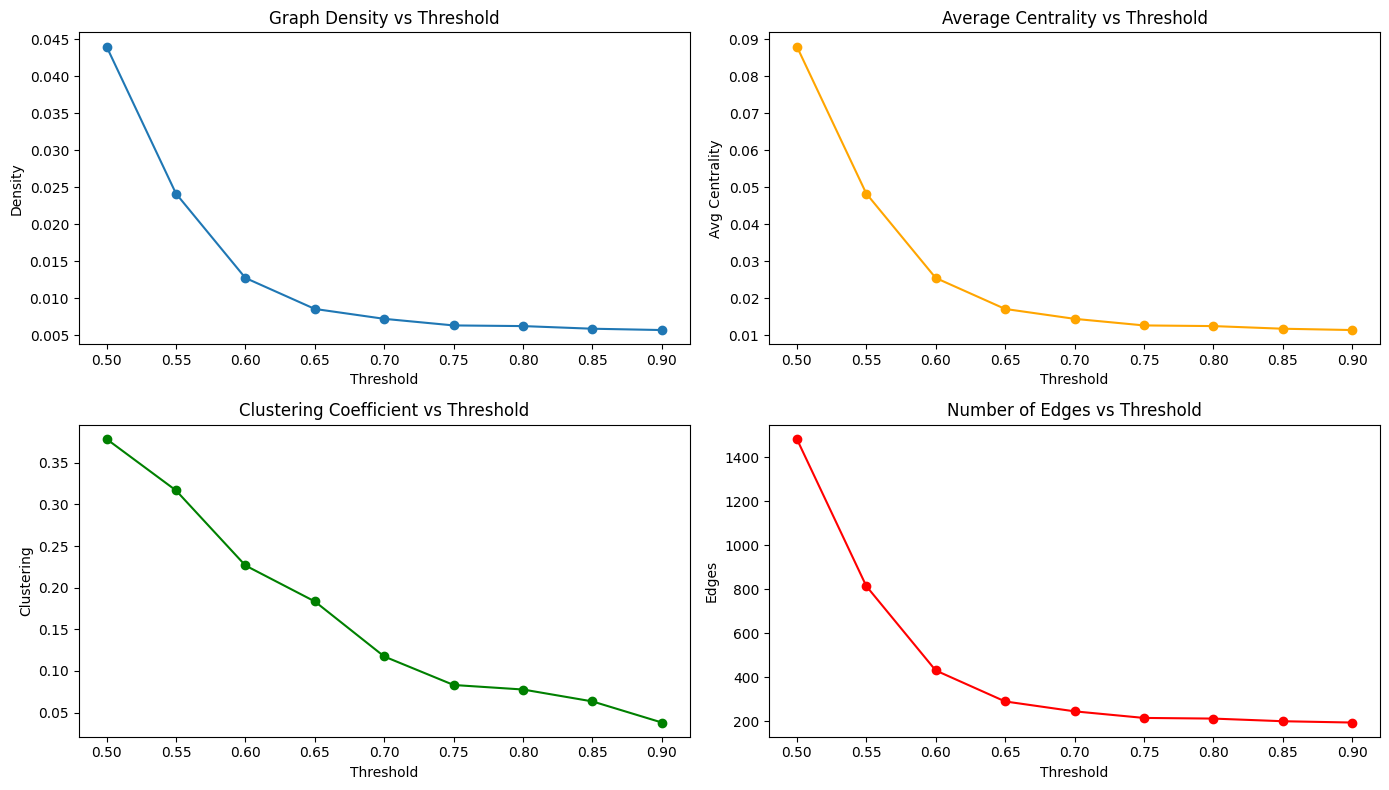

In [ ]:
import matplotlib.pyplot as plt

# Collect data for plotting
threshold_vals = []
density_vals = []
centrality_vals = []
clustering_vals = []
edge_counts = []
node_counts = []

num_nodes = len(all_indices)

# Re-run the metrics calculation to collect proper edge counts per threshold
for threshold in thresholds:
    G_metrics = nx.DiGraph()

    # Add nodes
    for idx, sent in enumerate(sentences):
        G_metrics.add_node(idx, text=sent["sentence"], role=sent["final_label"])

    # Build edges (using only the similarity score against the threshold)
    cosine_scores = util.pytorch_cos_sim(embeddings, embeddings)
    connected_list = [False] * len(all_indices)

    for i, src_idx in enumerate(all_indices):
        scores = cosine_scores[i].cpu().numpy()
        for tgt_idx, score in enumerate(scores):
            if src_idx == tgt_idx:
                continue
            if score >= threshold:
                G_metrics.add_edge(src_idx, tgt_idx, weight=1.0)
                connected_list[src_idx] = True

        # Fallback: connect to most similar neighbor if isolated
        if not connected_list[src_idx]:
            scores[src_idx] = -1
            tgt_idx = scores.argmax()
            G_metrics.add_edge(src_idx, tgt_idx, weight=1.0)

    # Compute metrics for the current threshold's structure
    density = nx.density(G_metrics)
    avg_centrality = sum(nx.degree_centrality(G_metrics).values()) / len(G_metrics.nodes)
    clustering = nx.average_clustering(G_metrics.to_undirected())

    # Store results
    threshold_vals.append(threshold)
    density_vals.append(density)
    centrality_vals.append(avg_centrality)
    clustering_vals.append(clustering)
    edge_counts.append(G_metrics.number_of_edges())


# Plot metrics vs threshold
plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
plt.plot(threshold_vals, density_vals, marker="o")
plt.title("Graph Density vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Density")

plt.subplot(2, 2, 2)
plt.plot(threshold_vals, centrality_vals, marker="o", color="orange")
plt.title("Average Centrality vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Avg Centrality")

plt.subplot(2, 2, 3)
plt.plot(threshold_vals, clustering_vals, marker="o", color="green")
plt.title("Clustering Coefficient vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Clustering")

plt.subplot(2, 2, 4)
plt.plot(threshold_vals, edge_counts, marker="o", color="red")
plt.title("Number of Edges vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Edges")

plt.tight_layout()
plt.show()

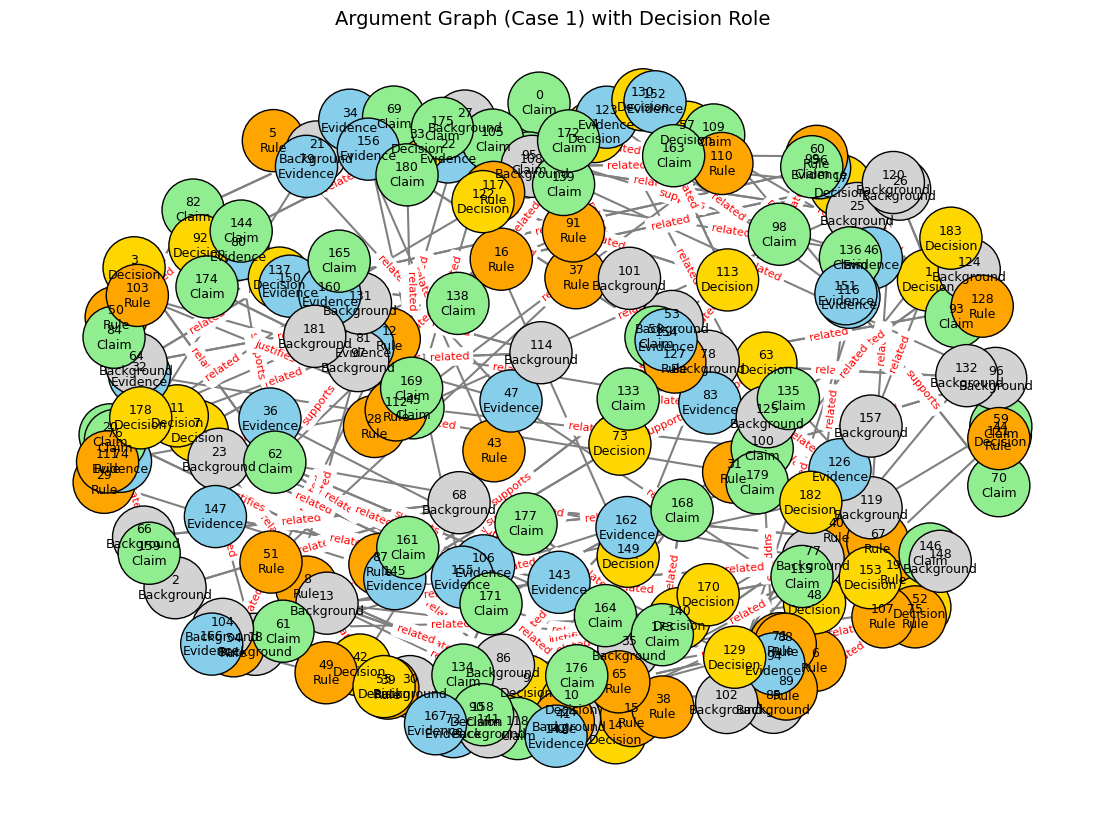

In [ ]:
# ------------------------------
# Load the graph from a .pkl file
# ------------------------------
graph_file = "graphs/case_1_graph.pkl"  # path to your saved graph

with open(graph_file, "rb") as f:
    G_loaded = pickle.load(f)

# Visualize
visualize_graph(G_loaded, title="Argument Graph (Case 1) with Decision Role")

SAVING GRAPHS FOR 0.65 0.70 0.75

In [ ]:
import json
import networkx as nx
import torch
import os
import pickle
from collections import Counter
from sentence_transformers import SentenceTransformer, util

# --- Configuration ---
CLASSIFIED_FILE = "classified_sentences.json"
THRESHOLDS = [0.65, 0.70, 0.75]
ARGUMENT_BOOST = 1.3
os.makedirs("graphs", exist_ok=True)

# --- Data and Model Preparation ---
# Load classified sentences
with open(CLASSIFIED_FILE, "r", encoding="utf-8") as f:
    sentences = json.load(f)

# Load embedder and calculate all embeddings/scores once
embedder = SentenceTransformer("all-MiniLM-L6-v2")

all_indices = list(range(len(sentences)))
all_texts = [sent["sentence"] for sent in sentences]
embeddings = embedder.encode(all_texts, convert_to_tensor=True)
cosine_scores = util.pytorch_cos_sim(embeddings, embeddings)

# --- Graph Generation Loop for all 3 Thresholds ---
for threshold in THRESHOLDS:
    G = nx.DiGraph()

    # 1. Add nodes
    for idx, sent in enumerate(sentences):
        G.add_node(idx, text=sent["sentence"], role=sent["final_label"])

    # 2. Build edges with Boosted Weights (incorporating 'Decision')
    connected_list = [False] * len(all_indices)

    for i, src_idx in enumerate(all_indices):
        scores = cosine_scores[i].cpu().numpy()

        # Prepare fallback index/score
        fallback_scores = scores.copy()
        fallback_scores[src_idx] = -1
        fallback_tgt_idx = fallback_scores.argmax()
        fallback_score = fallback_scores[fallback_tgt_idx]

        for tgt_idx, score in enumerate(scores):
            if src_idx == tgt_idx:
                continue

            if score >= threshold:
                connected_list[src_idx] = True

                src_role = G.nodes[src_idx]["role"]
                tgt_role = G.nodes[tgt_idx]["role"]

                relation = "related"
                boost = 1.0

                # Apply boost if the source supports/justifies a CLAIM OR DECISION
                if src_role in ["Evidence", "Premise"] and tgt_role in ["Claim", "Decision"]:
                    relation = "supports"
                    boost = ARGUMENT_BOOST
                elif src_role == "Rule" and tgt_role in ["Claim", "Decision"]:
                    relation = "justifies"
                    boost = ARGUMENT_BOOST

                new_weight = float(score) * boost
                G.add_edge(src_idx, tgt_idx, relation=relation, weight=new_weight)

        # 3. Isolation Fallback: connect to the single most similar neighbor
        if not connected_list[src_idx]:

            src_role = G.nodes[src_idx]["role"]
            tgt_role = G.nodes[fallback_tgt_idx]["role"]

            relation = "related"
            boost = 1.0

            # Apply boost if the fallback link satisfies the argumentative criteria
            if src_role in ["Evidence", "Premise"] and tgt_role in ["Claim", "Decision"]:
                relation = "supports"
                boost = ARGUMENT_BOOST
            elif src_role == "Rule" and tgt_role in ["Claim", "Decision"]:
                relation = "justifies"
                boost = ARGUMENT_BOOST

            new_weight = fallback_score * boost
            G.add_edge(src_idx, fallback_tgt_idx, relation=relation, weight=new_weight)

    # 4. Save the graph with the threshold in the filename
    filename = f"graphs/case_1_graph_{int(threshold*100)}.pkl"
    with open(filename, "wb") as f:
        pickle.dump(G, f)
    print(f"✅ Saved graph for Threshold {threshold} to {filename}. Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

✅ Saved graph for Threshold 0.65 to graphs/case_1_graph_65.pkl. Nodes: 184, Edges: 289
✅ Saved graph for Threshold 0.7 to graphs/case_1_graph_70.pkl. Nodes: 184, Edges: 244
✅ Saved graph for Threshold 0.75 to graphs/case_1_graph_75.pkl. Nodes: 184, Edges: 214
